# LightGBM softmax reranker for two-tower recipe candidates

The second stage of the recommender. The two-tower model (`model_training_twotowers.ipynb`) only measures
distance: it retrieves candidates by cosine similarity. Rating labels come only from this notebook, which
trains a LightGBM **multiclass** model. Each boosting round grows one tree per rating, and a **softmax**
over the five scores gives **P(rating = k), k = 1…5** for each (user, recipe) pair. Candidates are then
reranked by those probabilities, and each gets a predicted rating label.

```text
user's earlier ratings ─► two-tower user vector ─┐
                                                 ├─ cosine ─► top 200 candidates (recommend_recipes)
recipe content ─────────► two-tower item vector ─┘                        │
                                                                          ▼
      features as of the cutoff day: two-tower similarity; user, recipe and user × nutrition-cluster
      rating statistics from earlier days; nutrition and price
                                                                          │
                      LightGBM multiclass: raw scores z₁ … z₅, P(k) = exp zₖ / Σⱼ exp zⱼ (softmax)
                                                                          ▼
                              rerank by E[rating] = Σₖ k · P(k)   (or P(rating ≥ 4), P(rating = 5))
```

**Same data, no leakage**

- Ratings come from the two-tower artifacts: `observed_ratings.csv` is the deduplicated 1–5★ ratings of
  `input_stage2/recipe_user_ratings.csv` (rows with rating 0 are cut there).
- The reranker trains only on **ratings the two-tower never trained on**: its held-out rows (each user's
  last ratings) and the ratings its user/recipe filter dropped. Early stopping did look at the held-out
  rows, so the final numbers come from a separate test split. The two-tower split is rebuilt with the
  same `core_filter` and `per_user_split`, then checked against the saved user vocabulary. The checkpoint
  must also reproduce the saved `item_vectors.npy`.
- Every feature is computed **as of the row's UTC day** from ratings on strictly earlier days, the same
  rule the two-tower history uses. A row never sees its own rating, and serving builds features the same way.
- These rows are split 70 / 15 / 15, stratified on rating: reranker train, validation (early
  stopping) and test (report only).

**Balanced training, calibrated probabilities.** `CLASS_WEIGHT = "balanced"` weights each rating by
n / (5 × count), scikit-learn's formula, so every rating carries the same total weight while the trees are
fit. A class-weighted softmax learns probabilities proportional to wₖ · P(k), so
`predict_rating_probabilities(..., class_weights)` divides by the weights and reports P(rating = k) for the
true rating mix. The predicted label is the balanced decision, argmax P(k) / prior(k). On the v3
two-tower's features, balanced training with the weighting undone matched unweighted training (log loss
0.655 vs 0.654, balanced accuracy 0.389 vs 0.391). The raw weighted softmax had log loss 1.30.

**Run order.** Train and save the two-tower model first; this notebook refuses a `two_tower.pt` that does
not match the current `TwoTowerModel`. Then run this notebook top to bottom. Retrain the reranker whenever
`two_tower.pt` changes, because the saved reranker is tied to its sha256.

In [1]:
# Run once if these packages are missing, then restart the notebook kernel.
# %pip install lightgbm torch transformers==5.17.0 numpy pandas scikit-learn joblib matplotlib
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from IPython.display import display

In [2]:
RANDOM_STATE = 42
NOTEBOOK_DIR = next((p for p in (Path.cwd(), Path.cwd() / "DataMappingRecommendation")
                     if (p / "model_training_twotowers.ipynb").is_file()), None)
if NOTEBOOK_DIR is None:
    raise FileNotFoundError("Run from DataMappingRecommendation or its project root.")
TWO_TOWER_NOTEBOOK = NOTEBOOK_DIR / "model_training_twotowers.ipynb"
TWO_TOWER_DIR = NOTEBOOK_DIR / "model_artifacts/two_tower"
RERANKER_DIR = NOTEBOOK_DIR / "model_artifacts/reranker"
RERANK_VALIDATION_FRACTION = 0.15  # Early stopping.
RERANK_TEST_FRACTION = 0.15  # Final report only.
BAYES_STRENGTH = 10.0  # Pseudo-ratings that shrink user and recipe means toward the prior.
CLASS_WEIGHT = "balanced"  # n / (5 × count) per rating while fitting, undone for P. None: unweighted.
RUN_SIMILARITY_ABLATION = True  # Also fit without the two-tower similarity, to measure what it adds.
LIGHTGBM_OVERRIDES = {}  # Merged over LIGHTGBM_PARAMS (reranker-core), e.g. {"num_leaves": 31}.
NUM_BOOST_ROUND = 3000
EARLY_STOPPING_ROUNDS = 100
TWO_TOWER_BATCH_SIZE = 1024
RETRIEVE_K = 200  # Two-tower candidates per user.
TOP_K = 20
RERANK_SCORE = "expected_rating"  # Or "p_at_least_4", "p_rating_5".
NDCG_K = 10

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
device = torch.device("cuda" if torch.cuda.is_available() else
                      "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}; two-tower artifacts: {TWO_TOWER_DIR}")

Device: mps; two-tower artifacts: /Users/tung/Desktop/Học/Projects/ProjectSem1_2/DataMappingRecommendation/model_artifacts/two_tower


In [3]:
# Reuse the two-tower notebook's definitions (model, histories, catalog helpers) rather than copying them.
two_tower_notebook = json.loads(TWO_TOWER_NOTEBOOK.read_text())
for tag in ("two-tower-core", "two-tower-features"):
    tagged = [cell for cell in two_tower_notebook["cells"] if tag in cell.get("metadata", {}).get("tags", [])]
    if len(tagged) != 1:
        raise RuntimeError(f"Expected one cell tagged {tag!r} in {TWO_TOWER_NOTEBOOK.name}.")
    exec(compile("".join(tagged[0]["source"]), f"{TWO_TOWER_NOTEBOOK.name}:{tag}", "exec"), globals())
print(f"Loaded the two-tower-core and two-tower-features cells from {TWO_TOWER_NOTEBOOK.name}")

Loaded the two-tower-core and two-tower-features cells from model_training_twotowers.ipynb


In [4]:
"""LightGBM softmax reranker: P(rating = k), k = 1..5, for two-tower candidates.

The two-tower model only measures distance (cosine similarity); rating labels come from here.
Every feature is computed as of the row's UTC day from ratings on strictly earlier days, so a
training row never sees its own rating and served candidates see the same kind of history.
Requires the two-tower-core and two-tower-features cells of model_training_twotowers.ipynb.
"""
import hashlib
import json
from pathlib import Path
import re
import sys

import lightgbm as lgb
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import f1_score, log_loss
from sklearn.model_selection import train_test_split
from torch.nn import functional as F
from torch.utils.data import DataLoader

RERANKER_FORMAT = "recipe_lightgbm_reranker_v1"
RERANKER_MODEL_FILE, RERANKER_CONFIG_FILE = "lightgbm_reranker.txt", "config.json"
RATING_VALUES = np.arange(1, NUM_RATING_CLASSES + 1, dtype=np.float64)
PROBABILITY_COLUMNS = [f"p_rating_{rating}" for rating in range(1, NUM_RATING_CLASSES + 1)]
RERANK_SCORES = ("expected_rating", "p_at_least_4", "p_rating_5")
DAY_SPAN = 1 << 20  # Day numbers (days since 1970) stay below this; it separates entities in sort keys.
CONTENT_COLUMNS = [*NUTRITION_COLUMNS, "price_total_known", "price_missing_count", "price_error_dollars"]
# LightGBM rewrites spaces and brackets in feature names; snake_case keeps names identical after saving.
CONTENT_FEATURES = [re.sub(r"[^0-9a-z]+", "_", column.lower()).strip("_") for column in CONTENT_COLUMNS]
CATEGORICAL_FEATURES = ["nutrition_cluster"]
_STAT_FEATURES = ["count", "mean", "bayes_mean", "std",
                  *[f"share_{rating}" for rating in range(1, NUM_RATING_CLASSES + 1)],
                  "days_since_first", "days_since_last"]
FEATURE_COLUMNS = [
    "two_tower_similarity", "user_known",
    *[f"user_{name}" for name in _STAT_FEATURES], *[f"item_{name}" for name in _STAT_FEATURES],
    "user_cluster_count", "user_cluster_mean", "user_cluster_share", "bias_baseline",
    *CATEGORICAL_FEATURES, *CONTENT_FEATURES,
]
# PyTorch and LightGBM each bundle a libomp on macOS; once torch is loaded, multithreaded LightGBM
# segfaults. One thread avoids that and is fast enough at this data size.
LIGHTGBM_THREADS = 1 if sys.platform == "darwin" else 0
# Chosen on the reranker validation split (lowest multi-logloss among the variants tried).
LIGHTGBM_PARAMS = {
    "learning_rate": 0.03, "num_leaves": 15, "min_data_in_leaf": 400, "feature_fraction": 0.7,
    "bagging_fraction": 0.8, "bagging_freq": 1, "lambda_l2": 10.0, "max_bin": 255,
    "seed": 42, "deterministic": True, "force_row_wise": True, "verbose": -1,
    "num_threads": LIGHTGBM_THREADS,
}


def utc_day_numbers(dates):
    """Days since 1970-01-01 of each timestamp's UTC calendar day."""
    stamps = pd.to_datetime(pd.Series(dates).reset_index(drop=True), utc=True)
    if stamps.isna().any():
        raise ValueError("Dates must be valid timestamps.")
    days = stamps.dt.tz_convert(None).to_numpy().astype("datetime64[D]").astype(np.int64)
    if len(days) and (days.min() < 0 or days.max() >= DAY_SPAN):
        raise ValueError("Dates must fall between 1970 and the year 4840.")
    return days


class AsOfRatingStats:
    """Per-entity rating statistics over UTC days strictly before a cutoff day.

    History is sorted by (entity, day) and cumulatively summed, so each query is two binary
    searches. Entity code -1 means "no history" and always returns empty statistics.
    """
    def __init__(self, entity_codes, days, ratings):
        entity_codes, days = np.asarray(entity_codes, np.int64), np.asarray(days, np.int64)
        values = np.asarray(ratings, np.float64)
        if not len(entity_codes) == len(days) == len(values):
            raise ValueError("entity_codes, days, and ratings must have equal lengths.")
        if (entity_codes < 0).any() or (days < 0).any() or (days >= DAY_SPAN).any():
            raise ValueError("History needs nonnegative entity codes and day numbers below DAY_SPAN.")
        classes = rating_classes(values)
        keys = entity_codes * DAY_SPAN + days
        order = np.argsort(keys, kind="stable")
        self.keys, self.days = keys[order], days[order]
        # Columns: count, sum, sum of squares, then one count per rating class.
        columns = np.zeros((len(keys), 3 + NUM_RATING_CLASSES))
        columns[:, 0] = 1.0
        columns[:, 1] = values[order]
        columns[:, 2] = values[order] ** 2
        columns[np.arange(len(keys)), 3 + classes[order]] = 1.0
        self.cumulative = np.vstack([np.zeros((1, columns.shape[1])), np.cumsum(columns, axis=0)])

    def query(self, entity_codes, cutoff_days):
        entity_codes = np.asarray(entity_codes, np.int64)
        cutoff_days = np.broadcast_to(np.asarray(cutoff_days, np.int64), entity_codes.shape)
        if (cutoff_days < 0).any() or (cutoff_days >= DAY_SPAN).any():
            raise ValueError("Cutoff days must lie in [0, DAY_SPAN).")
        known = entity_codes >= 0
        start = np.where(known, entity_codes, 0) * DAY_SPAN
        lo = np.searchsorted(self.keys, start, side="left")
        hi = np.where(known, np.searchsorted(self.keys, start + cutoff_days, side="left"), lo)
        totals = self.cumulative[hi] - self.cumulative[lo]
        count = totals[:, 0]
        has = count > 0
        with np.errstate(invalid="ignore", divide="ignore"):
            mean = np.where(has, totals[:, 1] / count, np.nan)
            variance = np.maximum(totals[:, 2] - count * np.nan_to_num(mean) ** 2, 0.0) / (count - 1)
            shares = np.where(has[:, None], totals[:, 3:] / count[:, None], np.nan)
        days = self.days if len(self.days) else np.zeros(1, np.int64)
        first = days[np.clip(lo, 0, len(days) - 1)]
        last = days[np.clip(hi - 1, 0, len(days) - 1)]
        return {"count": count, "sum": totals[:, 1], "mean": mean,
                "std": np.where(count >= 2, np.sqrt(variance), np.nan), "shares": shares,
                "first_day": np.where(has, first, np.nan), "last_day": np.where(has, last, np.nan)}


class RerankFeatureBuilder:
    """Reranker features for (user, recipe, cutoff day) rows from ratings before the cutoff day.

    history holds every known star rating, 1-5 (user_id, item_index, rating, date); catalog rows
    are in item_index order. prior_mean shrinks sparse means (Bayesian average with bayes_strength
    pseudo-ratings); fit it on ratings disjoint from the reranker's own targets.
    """
    def __init__(self, history, catalog, prior_mean, user_lookup=None, bayes_strength=10.0):
        if not np.isfinite(prior_mean) or bayes_strength < 0:
            raise ValueError("Use a finite prior_mean and a nonnegative bayes_strength.")
        users = history["user_id"].map(canonical_id)
        if users.isna().any():
            raise ValueError("History user IDs cannot be missing.")
        self.user_codes = {user: code for code, user in enumerate(pd.unique(users))}
        user_codes = users.map(self.user_codes).to_numpy(np.int64)
        items = history["item_index"].to_numpy(np.int64)
        if len(items) and (items.min() < 0 or items.max() >= len(catalog)):
            raise ValueError("History item_index values must index catalog rows.")
        self.clusters = catalog["nutrition_cluster"].to_numpy(np.int64)
        if (self.clusters < 0).any():
            raise ValueError("nutrition_cluster must be a nonnegative integer label.")
        self.num_clusters = int(self.clusters.max()) + 1 if len(self.clusters) else 1
        days = utc_day_numbers(history["date"])
        ratings = history["rating"].to_numpy(np.float64)
        self.user_stats = AsOfRatingStats(user_codes, days, ratings)
        self.item_stats = AsOfRatingStats(items, days, ratings)
        self.user_cluster_stats = AsOfRatingStats(
            user_codes * self.num_clusters + self.clusters[items], days, ratings)
        self.content = catalog[CONTENT_COLUMNS].to_numpy(np.float32)
        self.known_users = {canonical_id(user) for user in (user_lookup or {})}
        self.prior_mean, self.bayes_strength = float(prior_mean), float(bayes_strength)

    def _bayes_mean(self, stats):
        return (stats["sum"] + self.bayes_strength * self.prior_mean) / (stats["count"] + self.bayes_strength)

    def transform(self, user_ids, item_indices, cutoff_days, similarity):
        users = pd.Series(user_ids).reset_index(drop=True).map(canonical_id)
        items = np.asarray(item_indices, np.int64)
        if len(users) != len(items):
            raise ValueError("user_ids and item_indices must have equal lengths.")
        if len(items) and (items.min() < 0 or items.max() >= len(self.clusters)):
            raise ValueError("item_indices must index catalog rows.")
        user_codes = users.map(self.user_codes).fillna(-1).to_numpy(np.int64)
        cutoff = np.broadcast_to(np.asarray(cutoff_days, np.int64), items.shape)
        clusters = self.clusters[items]
        stats = {"user": self.user_stats.query(user_codes, cutoff),
                 "item": self.item_stats.query(items, cutoff)}
        columns = {"two_tower_similarity": np.broadcast_to(np.asarray(similarity, np.float32), items.shape),
                   "user_known": users.isin(self.known_users).to_numpy(np.float32)}
        for prefix, values in stats.items():
            columns[f"{prefix}_count"] = values["count"]
            columns[f"{prefix}_mean"] = values["mean"]
            columns[f"{prefix}_bayes_mean"] = self._bayes_mean(values)
            columns[f"{prefix}_std"] = values["std"]
            for rating in range(1, NUM_RATING_CLASSES + 1):
                columns[f"{prefix}_share_{rating}"] = values["shares"][:, rating - 1]
            columns[f"{prefix}_days_since_first"] = cutoff - values["first_day"]
            columns[f"{prefix}_days_since_last"] = cutoff - values["last_day"]
        user_cluster = self.user_cluster_stats.query(
            np.where(user_codes >= 0, user_codes * self.num_clusters + clusters, -1), cutoff)
        columns["user_cluster_count"] = user_cluster["count"]
        columns["user_cluster_mean"] = user_cluster["mean"]
        with np.errstate(invalid="ignore", divide="ignore"):
            columns["user_cluster_share"] = np.where(
                stats["user"]["count"] > 0, user_cluster["count"] / stats["user"]["count"], np.nan)
        # Classic bias baseline: prior + user offset + item offset, both shrunk toward the prior.
        columns["bias_baseline"] = columns["user_bayes_mean"] + columns["item_bayes_mean"] - self.prior_mean
        columns["nutrition_cluster"] = clusters
        columns.update(zip(CONTENT_FEATURES, self.content[items].T))
        frame = pd.DataFrame(columns)[FEATURE_COLUMNS]
        floats = [column for column in FEATURE_COLUMNS if column not in CATEGORICAL_FEATURES]
        frame[floats] = frame[floats].astype(np.float32)
        return frame


def file_sha256(path):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for block in iter(lambda: handle.read(1 << 20), b""):
            digest.update(block)
    return digest.hexdigest()


def load_two_tower(directory, device="cpu"):
    """The saved two-tower model and its config; a checkpoint from another model version fails clearly."""
    directory = Path(directory)
    config = json.loads((directory / "config.json").read_text())
    checkpoint = torch.load(directory / "two_tower.pt", map_location="cpu", weights_only=True)
    try:
        model = TwoTowerModel(**checkpoint["model_config"])
        model.load_state_dict(checkpoint["state_dict"])
    except (TypeError, RuntimeError) as error:
        raise RuntimeError(
            f"{directory / 'two_tower.pt'} ({config.get('format_version', 'unknown format')}) does not "
            "match the TwoTowerModel now defined in model_training_twotowers.ipynb. Retrain and save the "
            "two-tower model there, then rerun this notebook.") from error
    return model.to(device).eval(), config


@torch.no_grad()
def two_tower_similarity(model, targets, history, item_features, max_history=64, batch_size=1024, device=None):
    """Two-tower similarity per row; history is the user's ratings before the row's day, target excluded."""
    if not len(targets):
        return np.empty(0, np.float32)
    device = torch.device(device) if device is not None else next(model.parameters()).device
    model.eval()
    dataset = HistoryDataset(targets, history, max_history=max_history,
                             half_life_days=model.config["half_life_days"], training=False)
    features = _feature_tensor(item_features, device)
    similarity = []
    for batch in DataLoader(dataset, batch_size=batch_size, shuffle=False):
        users = model.encode_users(*user_inputs(batch, features, device))
        item_ids = batch["item_index"].to(device)
        items = model.encode_items(features[item_ids], item_ids)
        similarity.append(model.similarity(users, items).cpu().numpy())
    return np.concatenate(similarity).astype(np.float32) if similarity else np.empty(0, np.float32)


def split_reranker_rows(rows, features, validation_fraction=0.15, test_fraction=0.15, seed=42):
    """Stratified random train / validation (early stopping) / test (final report) split.

    Returns {"train" | "validation" | "test": (rows, features)} with aligned, reset indexes.
    """
    if validation_fraction <= 0 or test_fraction <= 0 or validation_fraction + test_fraction >= 1:
        raise ValueError("Use positive validation and test fractions that sum to less than 1.")
    if len(rows) != len(features):
        raise ValueError("rows and features must be aligned.")
    positions, ratings = np.arange(len(rows)), rows["rating"].to_numpy()
    # Row counts, not chained fractions, so float rounding cannot move a row between splits.
    test_rows, validation_rows = (int(round(fraction * len(rows))) for fraction in (test_fraction, validation_fraction))
    rest, test = train_test_split(positions, test_size=test_rows, stratify=ratings, random_state=seed)
    train, validation = train_test_split(rest, test_size=validation_rows, stratify=ratings[rest],
                                         random_state=seed)
    return {name: (rows.iloc[part].reset_index(drop=True), features.iloc[part].reset_index(drop=True))
            for name, part in (("train", train), ("validation", validation), ("test", test))}


def balanced_class_weights(ratings, class_weight="balanced"):
    """Per-rating training weights; "balanced" is scikit-learn's n / (5 x count), None gives ones.

    A rating absent from training cannot be fit; it gets the largest (rarest-rating) weight.
    """
    if class_weight not in ("balanced", None):
        raise ValueError('class_weight must be "balanced" or None.')
    classes = rating_classes(ratings)
    if class_weight is None:
        return np.ones(NUM_RATING_CLASSES)
    if not len(classes):
        raise ValueError("Balanced class weights require at least one training rating.")
    counts = np.bincount(classes, minlength=NUM_RATING_CLASSES)
    weights = np.zeros(NUM_RATING_CLASSES)
    weights[counts > 0] = len(classes) / (NUM_RATING_CLASSES * counts[counts > 0])
    weights[counts == 0] = weights.max()
    return weights


def undo_class_weighting(probabilities, class_weights):
    """P(rating = k) from a class-weighted model: its softmax divided by w_k, renormalized.

    Class-weighted cross-entropy is minimized by q_k proportional to w_k * P(k | x), so dividing
    by the weights recovers probabilities that follow the true rating mix.
    """
    class_weights = np.asarray(class_weights, dtype=np.float64)
    if class_weights.shape != (NUM_RATING_CLASSES,) or not (class_weights > 0).all():
        raise ValueError("class_weights must hold one positive weight per rating.")
    unweighted = np.asarray(probabilities, dtype=np.float64) / class_weights
    return unweighted / unweighted.sum(axis=1, keepdims=True)


def class_prior(ratings):
    """Add-one smoothed rating shares, so every rating keeps a positive prior."""
    counts = np.bincount(rating_classes(ratings), minlength=NUM_RATING_CLASSES)
    return (counts + 1.0) / (counts.sum() + NUM_RATING_CLASSES)


def train_reranker(train_features, train_ratings, validation_features, validation_ratings,
                   params=None, class_weight="balanced", num_boost_round=3000, early_stopping_rounds=100,
                   log_period=100, feature_columns=None):
    """Multiclass (softmax) LightGBM on rating classes 0..4, early-stopped on validation log loss.

    Each boosting round adds one tree per rating; softmax over the five raw scores gives the
    model's class scores. With class_weight="balanced" every rating carries the same total
    weight in the loss (validation is weighted the same way); pass the returned class_weights
    to predict_rating_probabilities to get P(rating = k) for the true rating mix.
    """
    feature_columns = list(feature_columns or FEATURE_COLUMNS)
    categorical = [column for column in CATEGORICAL_FEATURES if column in feature_columns]
    train_labels, validation_labels = rating_classes(train_ratings), rating_classes(validation_ratings)
    class_weights = balanced_class_weights(train_ratings, class_weight=class_weight)
    params = {**LIGHTGBM_PARAMS, **(params or {}), "objective": "multiclass",
              "num_class": NUM_RATING_CLASSES, "metric": "multi_logloss"}
    train_set = lgb.Dataset(train_features[feature_columns], label=train_labels,
                            weight=class_weights[train_labels], categorical_feature=categorical,
                            free_raw_data=False)
    validation_set = lgb.Dataset(validation_features[feature_columns], label=validation_labels,
                                 weight=class_weights[validation_labels], reference=train_set,
                                 categorical_feature=categorical, free_raw_data=False)
    evaluations = {}
    callbacks = [lgb.early_stopping(early_stopping_rounds, first_metric_only=True, verbose=False),
                 lgb.record_evaluation(evaluations)]
    if log_period:
        callbacks.append(lgb.log_evaluation(log_period))
    booster = lgb.train(params, train_set, num_boost_round=num_boost_round,
                        valid_sets=[train_set, validation_set], valid_names=["train", "validation"],
                        callbacks=callbacks)
    history = pd.DataFrame({
        "iteration": np.arange(1, len(evaluations["train"]["multi_logloss"]) + 1),
        "train_multi_logloss": evaluations["train"]["multi_logloss"],
        "validation_multi_logloss": evaluations["validation"]["multi_logloss"],
    })
    return booster, history, class_weights


def predict_rating_probabilities(booster, features, class_weights=None):
    """P(rating = 1..5) per row from the booster's softmax.

    Pass the training class_weights to undo class weighting (calibrated probabilities); without
    them this returns the softmax as trained.
    """
    names = booster.feature_name()
    if missing := [name for name in names if name not in features.columns]:
        raise ValueError(f"Features {missing} are missing; the booster was trained on another feature set.")
    best = booster.best_iteration if booster.best_iteration > 0 else None
    probabilities = booster.predict(features[names], num_iteration=best, num_threads=LIGHTGBM_THREADS)
    probabilities = np.asarray(probabilities, dtype=np.float64).reshape(len(features), NUM_RATING_CLASSES)
    return probabilities if class_weights is None else undo_class_weighting(probabilities, class_weights)


def rerank_scores(probabilities):
    """Candidate scores derived from P(rating = 1..5)."""
    probabilities = np.asarray(probabilities, dtype=np.float64)
    return {"expected_rating": probabilities @ RATING_VALUES,
            "p_at_least_4": probabilities[:, 3:].sum(axis=1),
            "p_rating_5": probabilities[:, 4]}


def balanced_decisions(probabilities, prior):
    """Rating classes 0..4 chosen as argmax P(k) / prior(k).

    That is the Bayes decision if every rating were equally common: it gives the recall balance
    of class-weighted training while the probabilities themselves stay calibrated.
    """
    prior = np.asarray(prior, dtype=np.float64)
    if prior.shape != (NUM_RATING_CLASSES,) or (prior <= 0).any():
        raise ValueError("prior must hold one positive share per rating.")
    return (np.asarray(probabilities, dtype=np.float64) / prior).argmax(axis=1)


def rating_error_metrics(ratings, predicted_ratings, predicted_classes):
    """RMSE / MAE of predicted ratings, plus per-rating averages so each rating counts equally."""
    ratings = np.asarray(ratings, dtype=np.float64)
    errors = np.abs(ratings - np.asarray(predicted_ratings, dtype=np.float64))
    classes, present = rating_classes(ratings), np.unique(rating_classes(ratings))
    hits = np.asarray(predicted_classes) == classes
    return {"rmse": float(np.sqrt(np.mean(errors ** 2))), "mae": float(errors.mean()),
            "macro_mae": float(np.mean([errors[classes == c].mean() for c in present])),
            "balanced_accuracy": float(np.mean([hits[classes == c].mean() for c in present]))}


def probability_metrics(ratings, probabilities, prior=None):
    """Calibration (log loss), class decisions, and expected-rating error for P(rating = 1..5)."""
    ratings = np.asarray(ratings, dtype=np.float64)
    probabilities = np.asarray(probabilities, dtype=np.float64)
    classes, predicted = rating_classes(ratings), probabilities.argmax(axis=1)
    metrics = rating_error_metrics(ratings, probabilities @ RATING_VALUES, predicted)
    metrics.update({
        "log_loss": float(log_loss(classes, np.clip(probabilities, 1e-15, 1),
                                   labels=np.arange(NUM_RATING_CLASSES))),
        "accuracy": float(np.mean(predicted == classes)),
        "macro_f1": float(f1_score(classes, predicted, labels=np.arange(NUM_RATING_CLASSES),
                                   average="macro", zero_division=0)),
    })
    if prior is not None:
        decided = balanced_decisions(probabilities, prior)
        metrics["balanced_accuracy_prior_corrected"] = float(np.mean(
            [np.mean(decided[classes == c] == c) for c in np.unique(classes)]))
    return metrics


def probability_report(ratings, probabilities, prior):
    """Per rating: observed share vs mean P, and recall of the argmax and prior-corrected decisions."""
    classes = rating_classes(ratings)
    probabilities = np.asarray(probabilities, dtype=np.float64)
    decisions = {"argmax": probabilities.argmax(axis=1), "balanced": balanced_decisions(probabilities, prior)}
    rows = []
    for class_id in range(NUM_RATING_CLASSES):
        actual = classes == class_id
        row = {"rating": class_id + 1, "count": int(actual.sum()), "observed_share": float(actual.mean()),
               "mean_probability": float(probabilities[:, class_id].mean())}
        for name, decided in decisions.items():
            row[f"{name}_recall"] = float(np.mean(decided[actual] == class_id)) if actual.any() else np.nan
            row[f"{name}_predicted_share"] = float(np.mean(decided == class_id))
        rows.append(row)
    return pd.DataFrame(rows).set_index("rating")


def mean_ndcg(users, ratings, scores, k=10, seed=0):
    """Mean NDCG@k of each user's rows ordered by score, gain 2**rating - 1.

    Only users with at least two different ratings count (any order is ideal otherwise);
    ties are broken randomly with a fixed seed. Returns (mean NDCG, users evaluated).
    """
    frame = pd.DataFrame({"user": np.asarray(users), "rating": np.asarray(ratings, dtype=np.float64),
                          "score": np.asarray(scores, dtype=np.float64)})
    frame = frame[frame.groupby("user")["rating"].transform("nunique") >= 2]
    if frame.empty:
        return float("nan"), 0
    frame = frame.sample(frac=1.0, random_state=seed)

    def dcg(column):
        ranked = frame.sort_values(["user", column], ascending=[True, False], kind="stable")
        position = ranked.groupby("user", sort=False).cumcount().to_numpy()
        gains = np.where(position < k, (2.0 ** ranked["rating"].to_numpy() - 1) / np.log2(position + 2), 0.0)
        return pd.Series(gains, index=ranked.index).groupby(ranked["user"]).sum()

    ndcg = dcg("score") / dcg("rating")
    return float(ndcg.mean()), int(len(ndcg))


def ranking_report(users, ratings, named_scores, k=10, seed=0):
    """NDCG@k per score next to a random order; gap_closed = share of the random-to-ideal gap closed.

    Missing scores rank last.
    """
    random_scores = np.random.default_rng(seed).random(len(np.asarray(ratings)))
    random_ndcg, _ = mean_ndcg(users, ratings, random_scores, k, seed)
    rows = []
    for name, scores in {"random_order": random_scores, **named_scores}.items():
        scores = np.nan_to_num(np.asarray(scores, np.float64), nan=-np.inf)
        ndcg, evaluated = mean_ndcg(users, ratings, scores, k, seed)
        rows.append({"score": name, f"ndcg@{k}": ndcg, "users": evaluated,
                     "gap_closed": (ndcg - random_ndcg) / (1 - random_ndcg) if random_ndcg < 1 else np.nan})
    return pd.DataFrame(rows).set_index("score")


def shared_cutoff_rows(rows):
    """Serving-like evaluation rows: each user's rows share the day of that user's earliest row.

    At serving time every candidate is scored with one history, so ranking quality is measured
    with one cutoff per user: features and two-tower history come only from before that day,
    and the user's rows on or after it are the items to rank.
    """
    shared = rows.copy()
    shared["date"] = shared.groupby("user_id")["date"].transform("min").dt.floor("D")
    return shared


def save_reranker(directory, booster, feature_builder, two_tower_directory, metadata=None):
    """Write the booster (best iteration only) and a config tied to the exact two-tower checkpoint."""
    directory, two_tower_directory = Path(directory), Path(two_tower_directory)
    directory.mkdir(parents=True, exist_ok=True)
    booster.save_model(str(directory / RERANKER_MODEL_FILE),
                       num_iteration=booster.best_iteration if booster.best_iteration > 0 else None)
    two_tower_config = json.loads((two_tower_directory / "config.json").read_text())
    config = {
        "format_version": RERANKER_FORMAT, "model": "lightgbm", "objective": "multiclass",
        "activation": "softmax", "num_class": NUM_RATING_CLASSES, "rating_values": RATING_VALUES.tolist(),
        "probability_columns": PROBABILITY_COLUMNS, "feature_columns": FEATURE_COLUMNS,
        "categorical_features": CATEGORICAL_FEATURES, "content_columns": CONTENT_COLUMNS,
        "best_iteration": int(booster.best_iteration), "prior_mean": feature_builder.prior_mean,
        "bayes_strength": feature_builder.bayes_strength,
        "two_tower_artifact": {"sha256": file_sha256(two_tower_directory / "two_tower.pt"),
                               "format_version": two_tower_config.get("format_version")},
        **(metadata or {}),
    }
    (directory / RERANKER_CONFIG_FILE).write_text(json.dumps(config, indent=2, default=float) + "\n")
    return config


def load_reranker(directory, two_tower_directory):
    """The saved booster and config; refuses a two-tower checkpoint other than the one it was trained on."""
    directory = Path(directory)
    config = json.loads((directory / RERANKER_CONFIG_FILE).read_text())
    if config.get("format_version") != RERANKER_FORMAT:
        raise ValueError(f"Unsupported reranker format {config.get('format_version')!r}.")
    if file_sha256(Path(two_tower_directory) / "two_tower.pt") != config["two_tower_artifact"]["sha256"]:
        raise RuntimeError("two_tower.pt changed since this reranker was trained; retrain the reranker "
                           "on the current two-tower model.")
    booster = lgb.Booster(model_file=str(directory / RERANKER_MODEL_FILE))
    if booster.feature_name() != config["feature_columns"] or config["feature_columns"] != FEATURE_COLUMNS:
        raise ValueError("The saved reranker's features differ from FEATURE_COLUMNS; retrain the reranker.")
    return booster, config


@torch.no_grad()
def rerank_recipes(booster, feature_builder, model, catalog, item_features, interactions, user_id,
                   retrieve_k=200, top_k=10, as_of=None, max_history=64,
                   item_embeddings=None, score="expected_rating", class_weights=None, prior=None):
    """Two-tower top-retrieve_k candidates, reranked by LightGBM P(rating = 1..5).

    feature_builder must be built from the same ratings. A user without earlier ratings gets the
    most-liked recipes as candidates, with a missing two_tower_similarity.
    class_weights undoes training class weights; with prior, predicted_rating is the
    prior-corrected (balanced) decision, otherwise the most probable rating. With as_of=None,
    "now" is used, and recipes the user already reviewed are never returned
    (recommend_recipes' rule).
    """
    if score not in RERANK_SCORES:
        raise ValueError(f"score must be one of {RERANK_SCORES}.")
    if top_k < 1 or retrieve_k < top_k:
        raise ValueError("Use 1 <= top_k <= retrieve_k.")
    candidates = recommend_recipes(model, catalog, item_features, interactions, user_id,
                                   top_k=retrieve_k, as_of=as_of,
                                   max_history=max_history, item_embeddings=item_embeddings)
    candidates = candidates.rename(columns={"similarity": "two_tower_similarity"})
    candidates.insert(0, "two_tower_rank", np.arange(1, len(candidates) + 1))
    if candidates.empty:
        return candidates
    positions = pd.Index(catalog["recipe_id"].map(canonical_id)).get_indexer(
        candidates["recipe_id"].map(canonical_id))
    cutoff = _utc_day(as_of if as_of is not None else pd.Timestamp.now(tz="UTC"))
    features = feature_builder.transform([user_id] * len(positions), positions, utc_day_numbers([cutoff])[0],
                                         candidates["two_tower_similarity"].to_numpy(np.float32))
    probabilities = predict_rating_probabilities(booster, features, class_weights)
    result = candidates.copy()
    result[PROBABILITY_COLUMNS] = probabilities
    for name, values in rerank_scores(probabilities).items():
        result[name] = values
    decisions = probabilities.argmax(axis=1) if prior is None else balanced_decisions(probabilities, prior)
    result["predicted_rating"] = decisions + 1
    result = result.sort_values([score, "two_tower_rank"], ascending=[False, True], kind="stable")
    result = result.head(top_k).reset_index(drop=True)
    result.insert(0, "rank", np.arange(1, len(result) + 1))
    return result

## Two-tower artifacts and the held-out rows

The rebuilt split (user/recipe filter, then each user's last ratings held out) must reproduce the saved
user vocabulary (the two-tower's training users) exactly, and the checkpoint must reproduce the saved
`item_vectors.npy`.

In [5]:
two_tower_model, two_tower_config = load_two_tower(TWO_TOWER_DIR, device)
catalog = pd.read_csv(TWO_TOWER_DIR / "catalog.csv", dtype={"recipe_id": "string"})
item_features = np.load(TWO_TOWER_DIR / "item_features.npy", allow_pickle=False)
item_vectors = np.load(TWO_TOWER_DIR / "item_vectors.npy", allow_pickle=False)
observed_ratings = pd.read_csv(TWO_TOWER_DIR / "observed_ratings.csv", dtype={"user_id": "string"})
observed_ratings["date"] = pd.to_datetime(observed_ratings["date"], utc=True)
vocabulary = pd.read_csv(TWO_TOWER_DIR / "user_vocabulary.csv", dtype={"user_id": "string"})
user_lookup = dict(zip(vocabulary["user_id"], vocabulary["user_index"].astype(int)))
MAX_HISTORY = int(two_tower_config["max_history"])
# Labels and rating features use 1-5 star ratings only (the two-tower artifacts hold nothing else).
rated_ratings = observed_ratings[observed_ratings["rating"] > 0].reset_index(drop=True)
print(f"{two_tower_config['format_version']}: {len(rated_ratings):,} ratings, {len(catalog):,} recipes, "
      f"{len(user_lookup):,} training users")

two_tower_train, _ = per_user_split(
    core_filter(observed_ratings, two_tower_config["min_user_ratings"], two_tower_config["min_recipe_ratings"]),
    two_tower_config["holdout_per_user"])
if build_user_lookup(two_tower_train) != user_lookup:
    raise RuntimeError("The rebuilt split does not reproduce the two-tower user vocabulary.")
# Reranker rows: ratings the two-tower never trained on (its held-out rows and everything its
# user/recipe filter dropped). A user rates a recipe at most once, so (user, recipe) identifies a row.
trained_pairs = pd.MultiIndex.from_frame(two_tower_train[["user_id", "item_index"]])
untrained = ~pd.MultiIndex.from_frame(rated_ratings[["user_id", "item_index"]]).isin(trained_pairs)
heldout_ratings = rated_ratings[untrained].reset_index(drop=True)
recomputed_vectors = encode_catalog(two_tower_model, item_features, device=device).numpy()
vector_gap = float(np.abs(recomputed_vectors - item_vectors).max())
if vector_gap > 1e-4:
    raise RuntimeError(f"two_tower.pt does not reproduce item_vectors.npy (max gap {vector_gap:.2e}); "
                       "re-save the two-tower artifacts together.")
print(f"Split reproduced: {len(two_tower_train):,} two-tower training ratings; {len(heldout_ratings):,} "
      f"ratings it never trained on; the checkpoint reproduces item_vectors.npy (max gap {vector_gap:.1e})")
del recomputed_vectors

recipe_two_tower_v10: 1,071,520 ratings, 231,637 recipes, 27,527 training users


Split reproduced: 523,833 two-tower training ratings; 547,687 ratings it never trained on; the checkpoint reproduces item_vectors.npy (max gap 0.0e+00)


In [6]:
# Each row's two-tower history is every rating before its day, as at serving time.
heldout_rows = heldout_ratings[["user_id", "item_index", "rating", "date"]].reset_index(drop=True)
heldout_similarity = two_tower_similarity(
    two_tower_model, heldout_rows, observed_ratings, item_features,
    max_history=MAX_HISTORY, batch_size=TWO_TOWER_BATCH_SIZE, device=device)
# The shrinkage prior comes from two-tower training ratings, disjoint from every reranker row.
feature_builder = RerankFeatureBuilder(
    rated_ratings, catalog, prior_mean=float(two_tower_train.loc[two_tower_train["rating"] > 0, "rating"].mean()),
    user_lookup=user_lookup, bayes_strength=BAYES_STRENGTH)
heldout_features = feature_builder.transform(
    heldout_rows["user_id"], heldout_rows["item_index"], utc_day_numbers(heldout_rows["date"]),
    heldout_similarity)
reranker_splits = split_reranker_rows(heldout_rows, heldout_features, RERANK_VALIDATION_FRACTION,
                                      RERANK_TEST_FRACTION, seed=RANDOM_STATE)
rating_index = pd.RangeIndex(1, NUM_RATING_CLASSES + 1, name="rating")
split_summary = pd.DataFrame({
    name: rows["rating"].astype(int).value_counts().reindex(rating_index, fill_value=0)
    for name, (rows, _) in reranker_splits.items()})
split_summary.loc["total"] = split_summary.sum()
display(split_summary)
display(heldout_features.describe().T[["mean", "min", "max"]]
        .assign(missing_share=heldout_features.isna().mean()).round(3))

,train,validation,test
rating,,,
1,7413,1589,1588
2,6517,1396,1397
3,16650,3568,3568
4,71290,15276,15276
5,281511,60324,60324
total,383381,82153,82153


,mean,min,max,missing_share
two_tower_similarity,-0.139,-0.427,5.750000e-01,0.000
user_known,0.617,0.000,1.000000e+00,0.000
user_count,248.184,0.000,7.656000e+03,0.000
user_mean,4.658,1.000,5.000000e+00,0.338
user_bayes_mean,4.705,3.117,4.998000e+00,0.000
user_std,0.511,0.000,2.828000e+00,0.400
user_share_1,0.008,0.000,1.000000e+00,0.338
user_share_2,0.012,0.000,1.000000e+00,0.338
user_share_3,0.041,0.000,1.000000e+00,0.338
user_share_4,0.193,0.000,1.000000e+00,0.338


## Train the softmax reranker

The `multiclass` objective is softmax cross-entropy. Each round fits five trees, one raw score zₖ per
rating. Training stops once validation multiclass log loss has not improved for `EARLY_STOPPING_ROUNDS`
rounds, and the best round is kept. With `CLASS_WEIGHT = "balanced"`, train and validation rows carry
their rating's weight. Missing statistics, such as a recipe with no earlier ratings, stay NaN, and
LightGBM learns which branch they take. The ablation refits without `two_tower_similarity`.

In [7]:
train_rows, train_features = reranker_splits["train"]
validation_rows, validation_features = reranker_splits["validation"]
test_rows, test_features = reranker_splits["test"]
reranker, reranker_history, reranker_class_weights = train_reranker(
    train_features, train_rows["rating"], validation_features, validation_rows["rating"],
    params=LIGHTGBM_OVERRIDES, class_weight=CLASS_WEIGHT, num_boost_round=NUM_BOOST_ROUND,
    early_stopping_rounds=EARLY_STOPPING_ROUNDS, log_period=100)
rating_prior = class_prior(train_rows["rating"])
best_round = reranker_history.iloc[reranker.best_iteration - 1]
print(f"Class weights {np.round(reranker_class_weights, 3).tolist()}; best round {reranker.best_iteration} of "
      f"{len(reranker_history)} ({reranker.best_iteration * NUM_RATING_CLASSES:,} trees): weighted log loss "
      f"train {best_round['train_multi_logloss']:.4f}, validation {best_round['validation_multi_logloss']:.4f}")
if RUN_SIMILARITY_ABLATION:
    ablation_columns = [column for column in FEATURE_COLUMNS if column != "two_tower_similarity"]
    ablation_reranker, _, _ = train_reranker(
        train_features, train_rows["rating"], validation_features, validation_rows["rating"],
        params=LIGHTGBM_OVERRIDES, class_weight=CLASS_WEIGHT, num_boost_round=NUM_BOOST_ROUND,
        early_stopping_rounds=EARLY_STOPPING_ROUNDS, log_period=0, feature_columns=ablation_columns)
    print(f"Ablation without two_tower_similarity: best round {ablation_reranker.best_iteration}")

[100]	train's multi_logloss: 1.41217	validation's multi_logloss: 1.43943


[200]	train's multi_logloss: 1.3871	validation's multi_logloss: 1.43424


[300]	train's multi_logloss: 1.36866	validation's multi_logloss: 1.434


Class weights [10.343, 11.766, 4.605, 1.076, 0.272]; best round 282 of 382 (1,410 trees): weighted log loss train 1.3718, validation 1.4338


Ablation without two_tower_similarity: best round 250


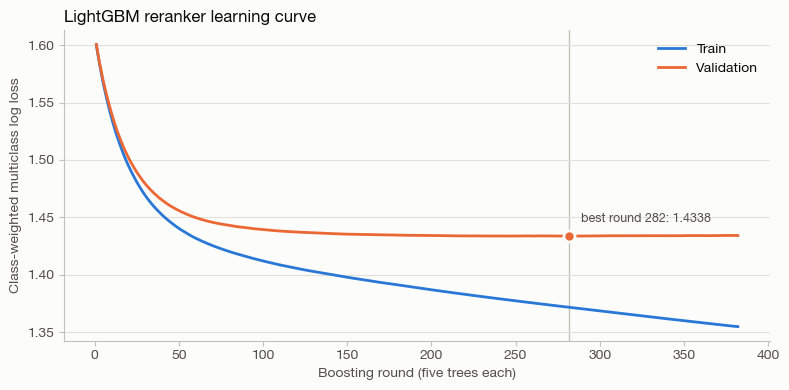

In [8]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

SURFACE, INK, INK_2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
VIZ_STYLE = {
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "font.sans-serif": ["Helvetica Neue", "Arial", "DejaVu Sans"],
    "font.size": 10, "text.color": INK, "axes.labelcolor": INK_2, "axes.titlesize": 12,
    "axes.titleweight": "semibold", "axes.titlelocation": "left", "axes.titlecolor": INK,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": AXIS, "ytick.color": AXIS, "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
}

with plt.rc_context(VIZ_STYLE):
    fig, ax = plt.subplots(figsize=(8, 4))
    for column, color, label in [("train_multi_logloss", BLUE, "Train"),
                                 ("validation_multi_logloss", ORANGE, "Validation")]:
        ax.plot(reranker_history["iteration"], reranker_history[column], color=color, linewidth=2, label=label)
    ax.axvline(reranker.best_iteration, color=AXIS, linewidth=1, zorder=0)
    ax.plot(reranker.best_iteration, best_round["validation_multi_logloss"], "o", markersize=8,
            color=ORANGE, markeredgecolor=SURFACE, markeredgewidth=2, zorder=3)
    ax.annotate(f"best round {reranker.best_iteration}: {best_round['validation_multi_logloss']:.4f}",
                (reranker.best_iteration, best_round["validation_multi_logloss"]), xytext=(8, 10),
                textcoords="offset points", color=INK_2, fontsize=9)
    ax.set(xlabel="Boosting round (five trees each)",
           ylabel="Class-weighted multiclass log loss" if CLASS_WEIGHT else "Multiclass log loss",
           title="LightGBM reranker learning curve")
    ax.grid(axis="x", visible=False)
    ax.legend(frameon=False, loc="upper right")
    fig.tight_layout()
    plt.show()

## Evaluation on the reranker test split

- **Probabilities.** Log loss scores the whole P(rating = k) vector. RMSE and MAE score E[rating]. Macro
  MAE and balanced accuracy weight every rating equally. `balanced_accuracy_prior_corrected` uses
  `balanced_decisions`, the argmax of P(k) divided by the prior, which is the label the reranker predicts.
- **Rows.** `lightgbm_reranker` has the class weighting undone. `lightgbm_as_trained` is the raw weighted
  softmax. `lightgbm_without_two_tower` is the ablation. `class_prior` predicts the training rating shares
  for every row. `bias_baseline` is prior + user offset + recipe offset, for RMSE and MAE only.
- **Ranking.** Serving scores all of a user's candidates with one history, so ranking is measured at one
  cutoff per user: the day of that user's earliest test row. Each user's test recipes rated on or after
  that day are ranked using only earlier ratings. NDCG@10 uses gain 2^rating − 1, over users with at least
  two different ratings. `gap_closed` is the share of the gap between random order and the ideal order
  that a score closes.

In [9]:
test_probabilities = predict_rating_probabilities(reranker, test_features, reranker_class_weights)
test_probabilities_as_trained = predict_rating_probabilities(reranker, test_features)
evaluation = {
    "class_prior": probability_metrics(test_rows["rating"], np.tile(rating_prior, (len(test_rows), 1)), rating_prior),
    "lightgbm_as_trained": probability_metrics(test_rows["rating"], test_probabilities_as_trained, rating_prior),
    "lightgbm_reranker": probability_metrics(test_rows["rating"], test_probabilities, rating_prior),
}
if RUN_SIMILARITY_ABLATION:
    evaluation["lightgbm_without_two_tower"] = probability_metrics(
        test_rows["rating"], predict_rating_probabilities(ablation_reranker, test_features, reranker_class_weights),
        rating_prior)
evaluation = pd.DataFrame(evaluation).T
bias_errors = test_rows["rating"].to_numpy() - test_features["bias_baseline"].to_numpy()
evaluation.loc["bias_baseline", ["rmse", "mae"]] = [np.sqrt(np.mean(bias_errors ** 2)), np.mean(np.abs(bias_errors))]
display(evaluation[["log_loss", "rmse", "mae", "macro_mae", "accuracy", "balanced_accuracy",
                    "balanced_accuracy_prior_corrected", "macro_f1"]].round(4))
probability_table = probability_report(test_rows["rating"], test_probabilities, rating_prior)
display(probability_table.round(4))

serving_rows = shared_cutoff_rows(test_rows)
serving_rows = serving_rows[serving_rows.groupby("user_id")["rating"].transform("nunique") >= 2].reset_index(drop=True)
serving_similarity = two_tower_similarity(
    two_tower_model, serving_rows, observed_ratings, item_features,
    max_history=MAX_HISTORY, batch_size=TWO_TOWER_BATCH_SIZE, device=device)
serving_features = feature_builder.transform(
    serving_rows["user_id"], serving_rows["item_index"], utc_day_numbers(serving_rows["date"]), serving_similarity)
serving_scores = rerank_scores(predict_rating_probabilities(reranker, serving_features, reranker_class_weights))
ranked_scores = {"two_tower_similarity": serving_similarity,
                 "item_bayes_mean": serving_features["item_bayes_mean"],
                 **{f"lightgbm_{name}": values for name, values in serving_scores.items()}}
if RUN_SIMILARITY_ABLATION:
    ranked_scores["lightgbm_without_two_tower_expected_rating"] = rerank_scores(predict_rating_probabilities(
        ablation_reranker, serving_features, reranker_class_weights))["expected_rating"]
ranking = ranking_report(serving_rows["user_id"], serving_rows["rating"], ranked_scores, k=NDCG_K,
                         seed=RANDOM_STATE)
print(f"Ranking {len(serving_rows):,} test recipes of {serving_rows['user_id'].nunique():,} users "
      "at one cutoff per user")
display(ranking.round(4))

,log_loss,rmse,mae,macro_mae,accuracy,balanced_accuracy,balanced_accuracy_prior_corrected,macro_f1
class_prior,0.8214,0.8131,0.5891,1.7593,0.7343,0.2000,0.2000,0.1694
lightgbm_as_trained,1.3766,1.5941,1.3973,1.0584,0.4049,0.3640,0.2777,0.2390
lightgbm_reranker,0.7367,0.7756,0.5189,1.6297,0.7408,0.2198,0.3640,0.2091
lightgbm_without_two_tower,0.7369,0.7758,0.5194,1.6304,0.7409,0.2195,0.3633,0.2085
bias_baseline,NaN,0.7903,0.4903,NaN,NaN,NaN,NaN,NaN


,count,observed_share,mean_probability,argmax_recall,argmax_predicted_share,balanced_recall,balanced_predicted_share
rating,,,,,,,
1,1588,0.0193,0.0187,0.0000,0.0000,0.6555,0.2606
2,1397,0.0170,0.0163,0.0000,0.0000,0.1611,0.0835
3,3568,0.0434,0.0425,0.0014,0.0001,0.2385,0.0971
4,15276,0.1859,0.1855,0.1191,0.0444,0.3330,0.1964
5,60324,0.7343,0.7371,0.9786,0.9555,0.4320,0.3624


Ranking 35,784 test recipes of 3,676 users at one cutoff per user


,ndcg@10,users,gap_closed
score,,,
random_order,0.8931,3676,0.0000
two_tower_similarity,0.8996,3676,0.0612
item_bayes_mean,0.9050,3676,0.1113
lightgbm_expected_rating,0.9113,3676,0.1701
lightgbm_p_at_least_4,0.9097,3676,0.1553
lightgbm_p_rating_5,0.9118,3676,0.1746
lightgbm_without_two_tower_expected_rating,0.9110,3676,0.1677


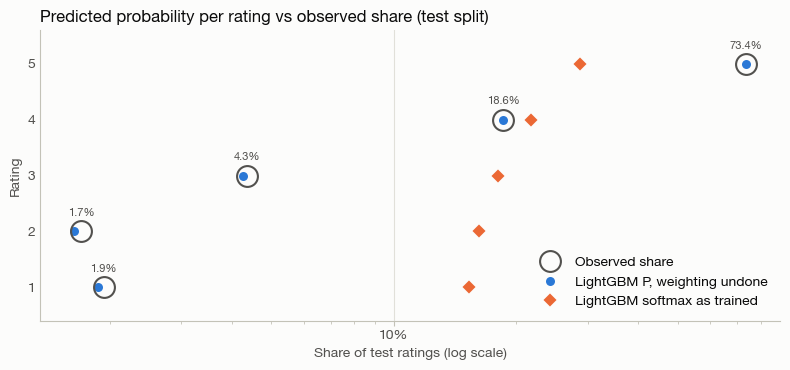

In [10]:
# Mean P(rating = k) against the observed share: a calibrated dot sits inside its observed ring.
shares = pd.DataFrame({
    "LightGBM P, weighting undone": probability_table["mean_probability"],
    "LightGBM softmax as trained": test_probabilities_as_trained.mean(axis=0),
}, index=probability_table.index)
with plt.rc_context(VIZ_STYLE):
    fig, ax = plt.subplots(figsize=(8, 3.8))
    ax.plot(probability_table["observed_share"], probability_table.index, "o", markersize=15,
            markerfacecolor="none", markeredgecolor=INK_2, markeredgewidth=1.5, linestyle="none",
            label="Observed share", zorder=3)
    for (label, values), color, marker in zip(shares.items(), [BLUE, ORANGE], ["o", "D"]):
        ax.plot(values, shares.index, marker, markersize=8, color=color, label=label,
                markeredgecolor=SURFACE, markeredgewidth=1.5, linestyle="none", zorder=2)
    for rating, share in probability_table["observed_share"].items():
        ax.annotate(f"{share:.1%}", (share, rating), xytext=(0, 11), textcoords="offset points",
                    ha="center", color=INK_2, fontsize=8)
    ax.set_xscale("log")
    ax.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
    ax.set(yticks=shares.index, ylim=(0.4, NUM_RATING_CLASSES + 0.6), xlabel="Share of test ratings (log scale)",
           ylabel="Rating", title="Predicted probability per rating vs observed share (test split)")
    ax.tick_params(axis="y", length=0)
    ax.grid(axis="y", visible=False)
    ax.legend(frameon=False, loc="lower right")
    fig.tight_layout()
    plt.show()

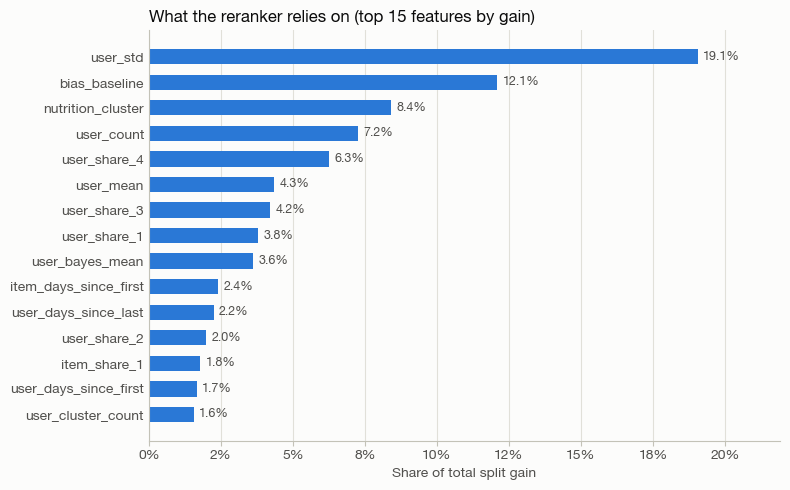

,gain_share
user_std,0.1905
bias_baseline,0.1210
nutrition_cluster,0.0840
user_count,0.0725
user_share_4,0.0626
user_mean,0.0435
user_share_3,0.0421
user_share_1,0.0380
user_bayes_mean,0.0361
item_days_since_first,0.0242


In [11]:
importance = pd.Series(reranker.feature_importance("gain"), index=reranker.feature_name())
importance = (importance / importance.sum()).sort_values(ascending=False)
top_importance = importance.head(15).iloc[::-1]
with plt.rc_context(VIZ_STYLE):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(range(len(top_importance)), top_importance, height=0.6, color=BLUE)
    ax.set_yticks(range(len(top_importance)), top_importance.index)
    for y, value in enumerate(top_importance):
        ax.annotate(f"{value:.1%}", (value, y), xytext=(4, 0), textcoords="offset points",
                    va="center", color=INK_2, fontsize=9)
    ax.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
    ax.set(xlim=(0, top_importance.max() * 1.15), xlabel="Share of total split gain",
           title="What the reranker relies on (top 15 features by gain)")
    ax.tick_params(axis="y", length=0)
    ax.grid(axis="y", visible=False)
    fig.tight_layout()
    plt.show()
display(importance.rename("gain_share").to_frame().round(4))

## Rerank one user's two-tower candidates

`rerank_recipes` takes the two-tower's top `RETRIEVE_K` recipes the user has not reviewed, computes the
features at the cutoff, and sorts them by `RERANK_SCORE`. Each row shows P(rating = 1…5), E[rating] and the
predicted rating label, next to the two-tower rank and similarity.

In [12]:
# The most active user whose ratings vary, so the probabilities differ across candidates.
user_profile = rated_ratings.groupby("user_id")["rating"].agg(["size", "mean", "nunique"])
varied_users = user_profile[(user_profile["nunique"] >= 4) & (user_profile["mean"] < 4.2)]
example_user_id = (varied_users if len(varied_users) else user_profile)["size"].idxmax()
example_as_of = observed_ratings["date"].max().floor("D") + pd.Timedelta(1, unit="D")
reranked = rerank_recipes(
    reranker, feature_builder, two_tower_model, catalog, item_features, observed_ratings, example_user_id,
    retrieve_k=RETRIEVE_K, top_k=TOP_K, as_of=example_as_of,
    max_history=MAX_HISTORY, item_embeddings=item_vectors, score=RERANK_SCORE,
    class_weights=reranker_class_weights, prior=rating_prior)
print(f"User {example_user_id} ({user_profile.loc[example_user_id, 'size']:,} ratings, mean "
      f"{user_profile.loc[example_user_id, 'mean']:.2f}): top {TOP_K} of {RETRIEVE_K} two-tower candidates, "
      f"reranked by {RERANK_SCORE}")
display(reranked[["rank", "two_tower_rank", "recipe_id", "name", "two_tower_similarity",
                  *PROBABILITY_COLUMNS, "expected_rating", "predicted_rating"]].round(3))

User 50969 (986 ratings, mean 4.17): top 20 of 200 two-tower candidates, reranked by expected_rating


,rank,two_tower_rank,recipe_id,name,two_tower_similarity,p_rating_1,p_rating_2,p_rating_3,p_rating_4,p_rating_5,expected_rating,predicted_rating
0,1,100,397572,rose s crunch dip,-0.041,0.002,0.008,0.052,0.446,0.491,4.415,4
1,2,7,445018,cook bacon in microwave or frypan,-0.016,0.004,0.003,0.047,0.465,0.481,4.415,4
2,3,150,401458,green beans in sour cream,-0.045,0.002,0.006,0.059,0.457,0.476,4.399,4
3,4,16,204657,sweet baby ray s bbq butter,-0.021,0.003,0.006,0.081,0.409,0.501,4.398,4
4,5,161,89181,tsr version of hard rock cafe creamy coleslaw ...,-0.046,0.002,0.007,0.073,0.428,0.490,4.398,4
5,6,57,298575,loaded potato fries,-0.035,0.003,0.004,0.071,0.445,0.477,4.389,4
6,7,33,434212,baked corn on the cob,-0.028,0.003,0.004,0.050,0.491,0.452,4.384,4
7,8,119,448205,savory italian seasoning salt,-0.042,0.002,0.006,0.076,0.441,0.476,4.383,4
8,9,116,199171,broiled cinnamon toast,-0.042,0.003,0.003,0.073,0.460,0.461,4.374,4
9,10,55,248495,make your own boursin cheese paula deen,-0.035,0.001,0.003,0.077,0.456,0.462,4.374,4


## Save the reranker

`model_artifacts/reranker/` holds `lightgbm_reranker.txt` (the best round only), `config.json` (features,
shrinkage prior, parameters, test metrics, and the sha256 of the `two_tower.pt` it was trained on),
`training_history.csv`, `test_metrics.csv` and `test_ranking.csv`. At serving time, `load_reranker` refuses
a different two-tower checkpoint. Build `RerankFeatureBuilder` from the star ratings (rating > 0) of the
same `observed_ratings.csv`, with the saved `prior_mean` and `bayes_strength`. Pass the saved `class_weights` and `rating_prior` to
`rerank_recipes` or `predict_rating_probabilities`.

In [13]:
reranker_config = save_reranker(RERANKER_DIR, reranker, feature_builder, TWO_TOWER_DIR, metadata={
    "class_weight": CLASS_WEIGHT, "class_weights": reranker_class_weights.tolist(),
    "rating_prior": rating_prior.tolist(), "lightgbm_params": {**LIGHTGBM_PARAMS, **LIGHTGBM_OVERRIDES},
    "rerank_score": RERANK_SCORE, "retrieve_k": RETRIEVE_K,
    "training_rows": "star ratings the two-tower never trained on (held-out rows and rows outside its k-core)",
    "split": {"validation_fraction": RERANK_VALIDATION_FRACTION, "test_fraction": RERANK_TEST_FRACTION,
              "seed": RANDOM_STATE, "rows": {name: len(rows) for name, (rows, _) in reranker_splits.items()}},
    "probabilities": "softmax / class_weights, renormalized (weighting undone)",
    "predicted_rating": "argmax P(k) / rating_prior(k)",
    "test_metrics": evaluation.loc["lightgbm_reranker"].to_dict(),
    "test_ranking": ranking[f"ndcg@{NDCG_K}"].to_dict(),
})
reranker_history.to_csv(RERANKER_DIR / "training_history.csv", index=False)
evaluation.to_csv(RERANKER_DIR / "test_metrics.csv")
ranking.to_csv(RERANKER_DIR / "test_ranking.csv")
restored_reranker, restored_config = load_reranker(RERANKER_DIR, TWO_TOWER_DIR)
np.testing.assert_allclose(predict_rating_probabilities(restored_reranker, test_features,
                                                        np.asarray(restored_config["class_weights"])),
                           test_probabilities, rtol=0, atol=1e-9)
print(f"Saved the reranker to {RERANKER_DIR.resolve()}; the restored booster reproduces the test probabilities")

Saved the reranker to /Users/tung/Desktop/Học/Projects/ProjectSem1_2/DataMappingRecommendation/model_artifacts/reranker; the restored booster reproduces the test probabilities
